In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df=pd.read_csv(os.path.join(path,'AB_NYC_2019.csv'))
df.head()

Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# missing value

In [8]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

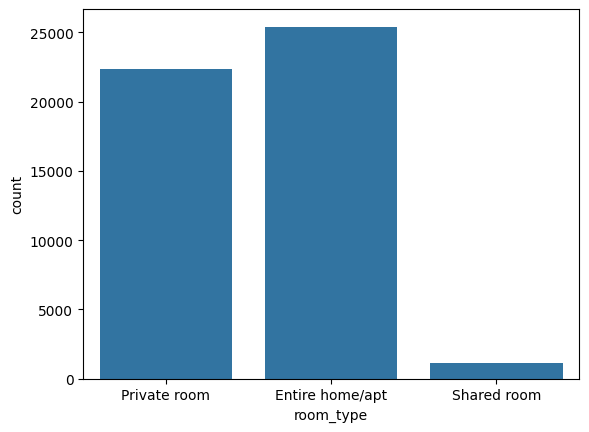

In [10]:
sns.countplot(data=df,x='room_type')

In [11]:
#univariate analysis

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

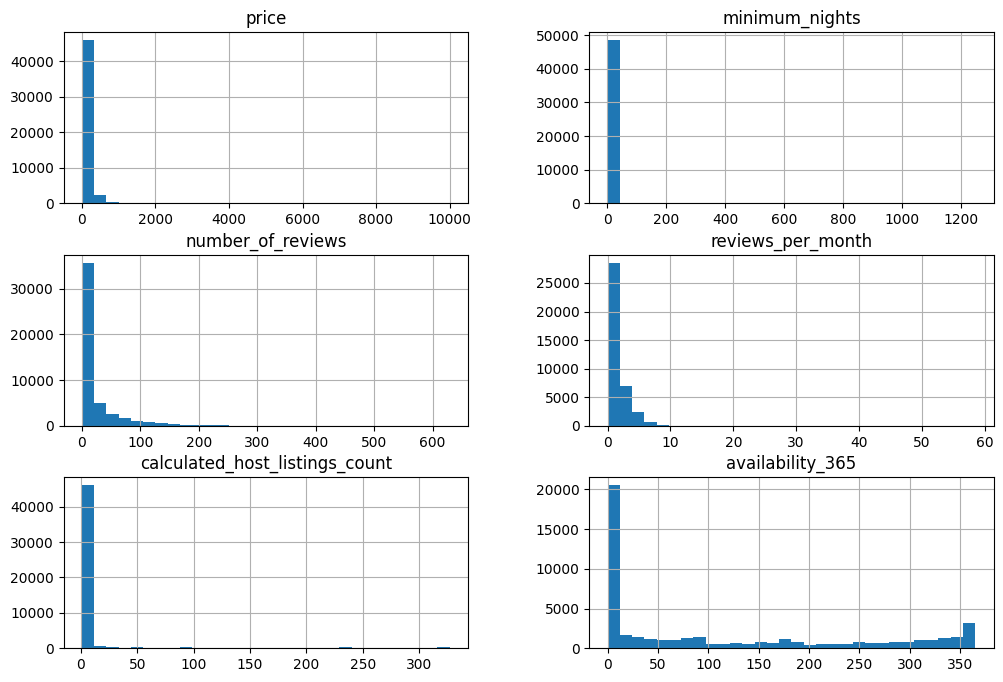

In [12]:
num_cols=['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count'	,'availability_365']
df[num_cols].hist(bins=30,figsize=(12,8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

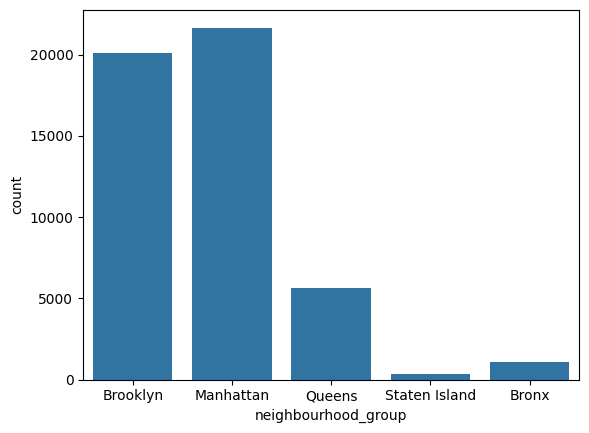

In [13]:
sns.countplot(data=df,x='neighbourhood_group')

In [14]:
# Bivariate Analysis

<Axes: xlabel='room_type', ylabel='price'>

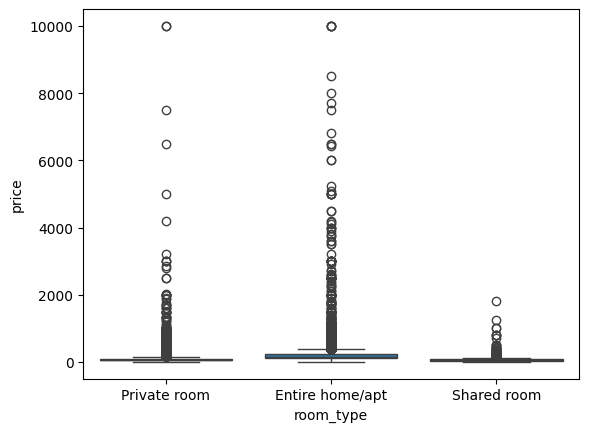

In [15]:
sns.boxplot(data=df,x='room_type',y='price')

In [16]:
# correlation  between Numeric Feature

In [17]:
corr=df[num_cols+['latitude','longitude']].corr()
corr

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,longitude
price,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829,0.033939,-0.150019
minimum_nights,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303,0.024869,-0.062747
number_of_reviews,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028,-0.015389,0.059094
reviews_per_month,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791,-0.010142,0.145948
calculated_host_listings_count,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701,0.019517,-0.114713
availability_365,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000,-0.010983,0.082731
latitude,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983,1.000000,0.084788
longitude,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731,0.084788,1.000000


<Axes: >

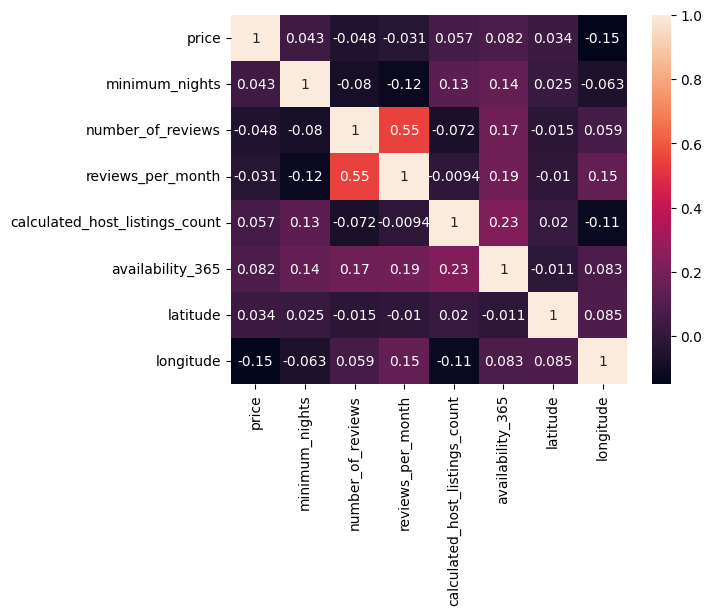

In [18]:
sns.heatmap(corr,annot=True)

In [19]:
#Geographic Distribution

<Axes: xlabel='longitude', ylabel='latitude'>

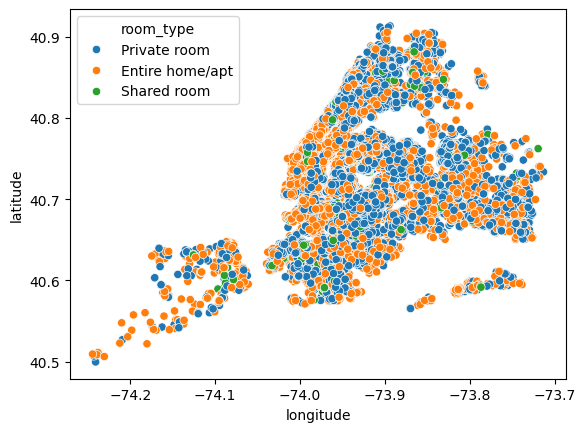

In [20]:
sns.scatterplot(x='longitude',y='latitude',data=df ,hue='room_type')

In [21]:
# Data Cleaning & feature Engineering

In [22]:
df_cleaned=df.drop(columns=['id','name','host_id','host_name','last_review'])

In [23]:
df_cleaned.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [24]:
df_cleaned['reviews_per_month']=df_cleaned['reviews_per_month'].fillna(0)

In [25]:
df_cleaned['reviews_per_month'].isna().sum()

np.int64(0)

In [26]:
# outlier

In [27]:
price_cap=df_cleaned['price'].quantile(0.99)
nights_cap=df_cleaned['minimum_nights'].quantile(0.99)
df_cleaned['price']=df_cleaned['price'].clip(upper=price_cap)
df_cleaned['minimum_nights']=df_cleaned['minimum_nights'].clip(upper=nights_cap)

In [28]:
df_cleaned

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [29]:
X=df_cleaned.drop(columns=['room_type'])
y=df_cleaned['room_type']

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
 X_train,X_test,y_train,y_test=train_test_split(X,y ,test_size=0.2,random_state=42,stratify=y)

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [33]:

numeric_cols=['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count'	,'availability_365']
cat_cols=['neighbourhood_group','neighbourhood']

# numeric Pipeline

numeric_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler()),
    
])

# categorical pPipeline

categorical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('numerical',numeric_pipeline,numeric_cols),
    ('categorical',categorical_pipeline,cat_cols)
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [35]:
models={
    'Logistic_Regression':LogisticRegression(class_weight='balanced',random_state=42),
    'Decision_Tree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'Random_Forest': RandomForestClassifier(class_weight='balanced',random_state=42),
    'Gradient_Boosting':GradientBoostingClassifier(random_state=42)
}

for name ,model in models.items():
    pipe=Pipeline(steps=[
        ('preprocessor',preprocessor),('classifier',model)
    ])
    accuracy=cross_val_score(pipe,X_train,y_train,cv=3,scoring="accuracy")
    macro_f1=cross_val_score(pipe,X_train,y_train,cv=3,scoring='f1_macro')
    
    print(f"{name}-> Accuracy: {accuracy.mean():.3f}, f1:{macro_f1.mean():.3f}")

Logistic_Regression-> Accuracy: 0.663, f1:0.526
Decision_Tree-> Accuracy: 0.784, f1:0.650
Random_Forest-> Accuracy: 0.853, f1:0.718
Gradient_Boosting-> Accuracy: 0.850, f1:0.708


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ('classifier',RandomForestClassifier(class_weight='balanced'))
])

param_distribution={
    'classifier__n_estimators':[100,200,150,300],
    'classifier__max_depth':[8,12,15,20,None],
    'classifier__min_samples_split':[2,5,100], 
    
}

searchCV=RandomizedSearchCV(estimator=best_pipeline,param_distributions=param_distribution,n_iter=10,cv=3,scoring='f1_macro',random_state=42)
searchCV.fit(X_train,y_train)

In [ ]:

print("Best Parameters: ", searchCV.best_params_)
print("Best CV Macro-F1: ", searchCV.best_score_)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = searchCV.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

In [ ]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)